In [1]:
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42
TARGET = "Price"

print("Python:", sys.executable)
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Everything is OK!")


Python: C:\Users\The Hoang\miniconda3\envs\ml\python.exe
Pandas: 3.0.5
NumPy: 2.4.6
Everything is OK!


In [2]:
DATA_PATH = "vietnam_housing_dataset.csv"
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        "Không tìm thấy vietnam_housing_dataset.csv. "
        "Hãy đặt file CSV cùng thư mục với notebook."
    )

df = pd.read_csv(DATA_PATH)
print(f"Dataset path: {DATA_PATH}")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
display(df.head())


Dataset path: vietnam_housing_dataset.csv
Rows: 30229
Columns: 12


,Address,Area,Frontage,Access Road,House direction,Balcony direction,Floors,Bedrooms,Bathrooms,Legal status,Furniture state,Price
0,"Dự án The Empire - Vinhomes Ocean Park 2, Xã L...",84.0,NaN,NaN,NaN,NaN,4.0,NaN,NaN,Have certificate,NaN,8.60
1,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",60.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,7.50
2,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",90.0,6.0,13.0,Đông - Bắc,Đông - Bắc,5.0,NaN,NaN,Sale contract,NaN,8.90
3,"Đường Nguyễn Văn Khối, Phường 11, Gò Vấp, Hồ C...",54.0,NaN,3.5,Tây - Nam,Tây - Nam,2.0,2.0,3.0,Have certificate,Full,5.35
4,"Đường Quang Trung, Phường 8, Gò Vấp, Hồ Chí Minh",92.0,NaN,NaN,Đông - Nam,Đông - Nam,2.0,4.0,4.0,Have certificate,Full,6.90


In [3]:
print("Columns:")
print(df.columns.tolist())
print("\nMissing values:")
print(df.isna().sum().sort_values(ascending=False).head(20))
print("\nData types:")
print(df.dtypes)
print("\nDescribe:")
display(df.describe(include="all").T)


Columns:
['Address', 'Area', 'Frontage', 'Access Road', 'House direction', 'Balcony direction', 'Floors', 'Bedrooms', 'Bathrooms', 'Legal status', 'Furniture state', 'Price']

Missing values:
Balcony direction    24983
House direction      21239
Furniture state      14119
Access Road          13297
Frontage             11564
Bathrooms             7074
Bedrooms              5162
Legal status          4506
Floors                3603
Area                     0
Address                  0
Price                    0
dtype: int64

Data types:
Address                  str
Area                 float64
Frontage             float64
Access Road          float64
House direction          str
Balcony direction        str
Floors               float64
Bedrooms             float64
Bathrooms            float64
Legal status             str
Furniture state          str
Price                float64
dtype: object

Describe:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Address,30229,10265,"Dự án The Empire - Vinhomes Ocean Park 2, Xã L...",187,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Area,30229.0,NaN,NaN,NaN,68.498741,48.069835,3.1,40.0,56.0,80.0,595.0
Frontage,18665.0,NaN,NaN,NaN,5.361692,4.346174,1.0,4.0,4.5,5.0,77.0
Access Road,16932.0,NaN,NaN,NaN,7.8538,7.451313,1.0,4.0,6.0,10.0,85.0
House direction,8990,8,Đông - Nam,1916,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Balcony direction,5246,8,Đông - Nam,1087,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Floors,26626.0,NaN,NaN,NaN,3.410426,1.328897,1.0,2.0,3.0,4.0,10.0
Bedrooms,25067.0,NaN,NaN,NaN,3.51103,1.309116,1.0,3.0,3.0,4.0,9.0
Bathrooms,23155.0,NaN,NaN,NaN,3.346837,1.400181,1.0,2.0,3.0,4.0,9.0
Legal status,25723,2,Have certificate,24774,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
model_df = df.copy()

if "Address" in model_df.columns:
    def extract_location(value):
        if pd.isna(value):
            return np.nan
        parts = [p.strip() for p in str(value).split(",") if p.strip()]
        if not parts:
            return np.nan
        return ", ".join(parts[-2:]) if len(parts) >= 2 else parts[-1]
    model_df["Location"] = model_df["Address"].apply(extract_location)

drop_cols = [c for c in ["id", "ID", "Address"] if c in model_df.columns]
model_df = model_df.drop(columns=drop_cols, errors="ignore")

model_df["Price"] = pd.to_numeric(model_df["Price"], errors="coerce")
model_df = model_df.dropna(subset=["Price"])

EXPECTED_NUMERIC = ["Area", "Frontage", "Access Road", "Floors", "Bedrooms", "Bathrooms"]
for col in EXPECTED_NUMERIC:
    if col in model_df.columns:
        model_df[col] = pd.to_numeric(model_df[col], errors="coerce")

print("After cleaning:", model_df.shape)
display(model_df.head())


After cleaning: (30229, 12)


,Area,Frontage,Access Road,House direction,Balcony direction,Floors,Bedrooms,Bathrooms,Legal status,Furniture state,Price,Location
0,84.0,NaN,NaN,NaN,NaN,4.0,NaN,NaN,Have certificate,NaN,8.60,"Văn Giang, Hưng Yên"
1,60.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,7.50,"Văn Giang, Hưng Yên"
2,90.0,6.0,13.0,Đông - Bắc,Đông - Bắc,5.0,NaN,NaN,Sale contract,NaN,8.90,"Văn Giang, Hưng Yên"
3,54.0,NaN,3.5,Tây - Nam,Tây - Nam,2.0,2.0,3.0,Have certificate,Full,5.35,"Gò Vấp, Hồ Chí Minh"
4,92.0,NaN,NaN,Đông - Nam,Đông - Nam,2.0,4.0,4.0,Have certificate,Full,6.90,"Gò Vấp, Hồ Chí Minh"


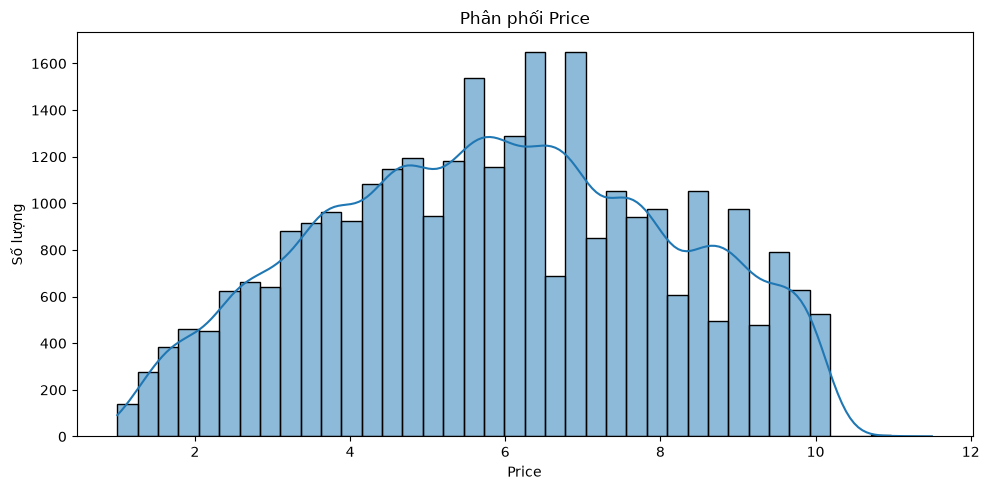

In [5]:
plt.figure(figsize=(10, 5))
sns.histplot(model_df["Price"].dropna(), bins=40, kde=True)
plt.title("Phân phối Price")
plt.xlabel("Price")
plt.ylabel("Số lượng")
plt.tight_layout()
plt.show()


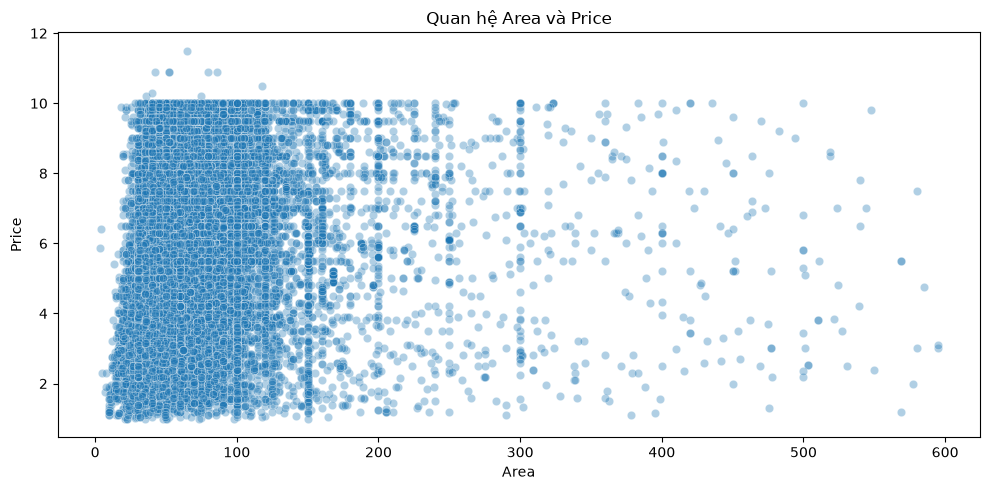

In [6]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=model_df, x="Area", y="Price", alpha=0.35)
plt.title("Quan hệ Area và Price")
plt.tight_layout()
plt.show()


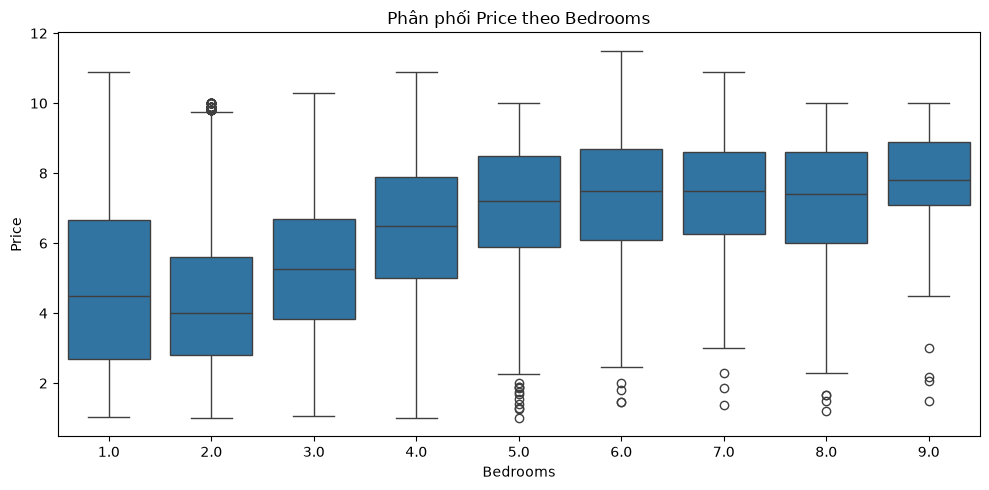

In [7]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=model_df, x="Bedrooms", y="Price")
plt.title("Phân phối Price theo Bedrooms")
plt.tight_layout()
plt.show()


In [8]:
TARGET = "Price"
X = model_df.drop(columns=[TARGET])
y = model_df[TARGET].astype(float)

numeric_features = [c for c in ["Area", "Frontage", "Access Road", "Floors", "Bedrooms", "Bathrooms"] if c in X.columns]
categorical_features = [c for c in ["House direction", "Balcony direction", "Legal status", "Furniture state", "Location"] if c in X.columns]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)
print("X shape:", X.shape)
print("y shape:", y.shape)


Numeric features: ['Area', 'Frontage', 'Access Road', 'Floors', 'Bedrooms', 'Bathrooms']
Categorical features: ['House direction', 'Balcony direction', 'Legal status', 'Furniture state', 'Location']
X shape: (30229, 11)
y shape: (30229,)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE
)
print(f"Training samples: {len(X_train):,}")
print(f"Testing samples: {len(X_test):,}")


Training samples: 24,183
Testing samples: 6,046


In [10]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)
print("Preprocessing pipeline ready")


Preprocessing pipeline ready


In [11]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(
        random_state=RANDOM_STATE,
        max_depth=20,
        min_samples_leaf=2
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        max_depth=25,
        min_samples_leaf=2
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        random_state=RANDOM_STATE,
        loss="huber"
    )
}

pipelines = {
    name: Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    for name, model in models.items()
}

print("Models:", list(pipelines.keys()))


Models: ['Linear Regression', 'Ridge Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting']


In [12]:
def mean_absolute_percentage_error_safe(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = y_true != 0
    if not np.any(mask):
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

results = []
predictions = {}

for name, pipeline in pipelines.items():
    print(f"Training: {name} ...")
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    predictions[name] = y_pred

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error_safe(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "MAPE (%)": mape,
        "R2": r2
    })


Training: Linear Regression ...
Training: Ridge Regression ...
Training: Decision Tree ...
Training: Random Forest ...
Training: Gradient Boosting ...


In [13]:
results_df = pd.DataFrame(results)

results_df["Rank_MAE"] = results_df["MAE"].rank(method="min")
results_df["Rank_RMSE"] = results_df["RMSE"].rank(method="min")
results_df["Rank_MAPE"] = results_df["MAPE (%)"].rank(method="min")
results_df["Rank_R2"] = results_df["R2"].rank(method="min", ascending=False)
results_df["Average Rank"] = results_df[["Rank_MAE", "Rank_RMSE", "Rank_MAPE", "Rank_R2"]].mean(axis=1)
results_df = results_df.sort_values("Average Rank").reset_index(drop=True)

display(results_df[["Model", "MAE", "MSE", "RMSE", "MAPE (%)", "R2", "Average Rank"]].round(4))


,Model,MAE,MSE,RMSE,MAPE (%),R2,Average Rank
0,Random Forest,1.1460,2.3004,1.5167,24.9358,0.5282,1.0
1,Linear Regression,1.2792,2.7145,1.6476,27.3109,0.4433,3.0
2,Ridge Regression,1.2820,2.7071,1.6453,27.3556,0.4448,3.0
3,Gradient Boosting,1.2873,2.6589,1.6306,28.8316,0.4547,3.5
4,Decision Tree,1.2822,2.8657,1.6928,27.5503,0.4123,4.5


In [14]:
print("BEST MODEL")
best_model_name = results_df.iloc[0]["Model"]
best_pipeline = pipelines[best_model_name]
best_row = results_df.iloc[0]
print("Model:", best_model_name)
print(f"MAE: {best_row['MAE']:.6f}")
print(f"MSE: {best_row['MSE']:.6f}")
print(f"RMSE: {best_row['RMSE']:.6f}")
print(f"MAPE: {best_row['MAPE (%)']:.2f}%")
print(f"R2: {best_row['R2']:.6f}")

BEST MODEL
Model: Random Forest
MAE: 1.146005
MSE: 2.300436
RMSE: 1.516719
MAPE: 24.94%
R2: 0.528204


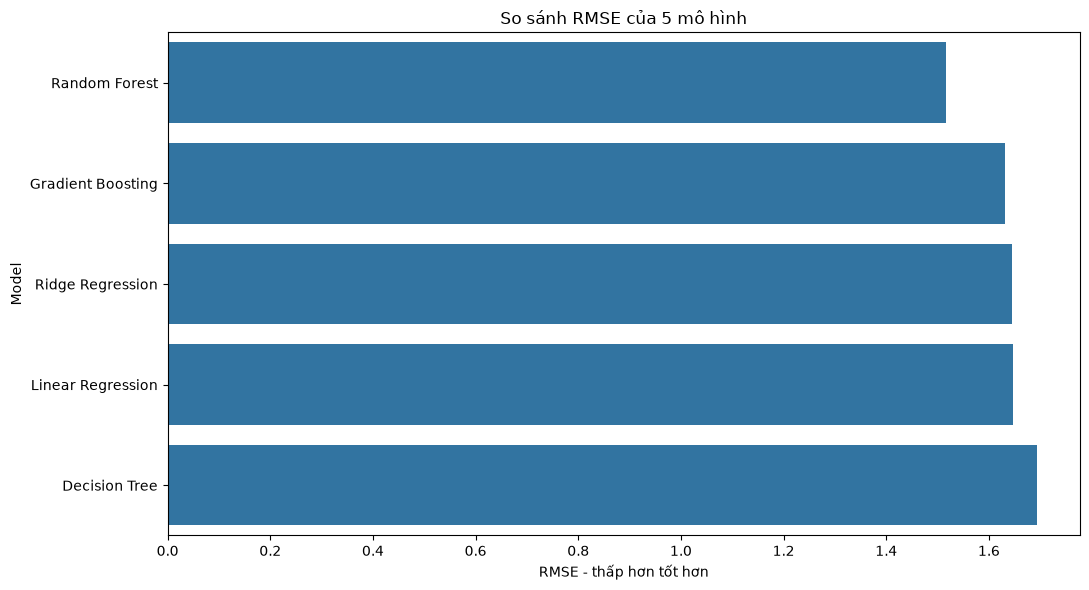

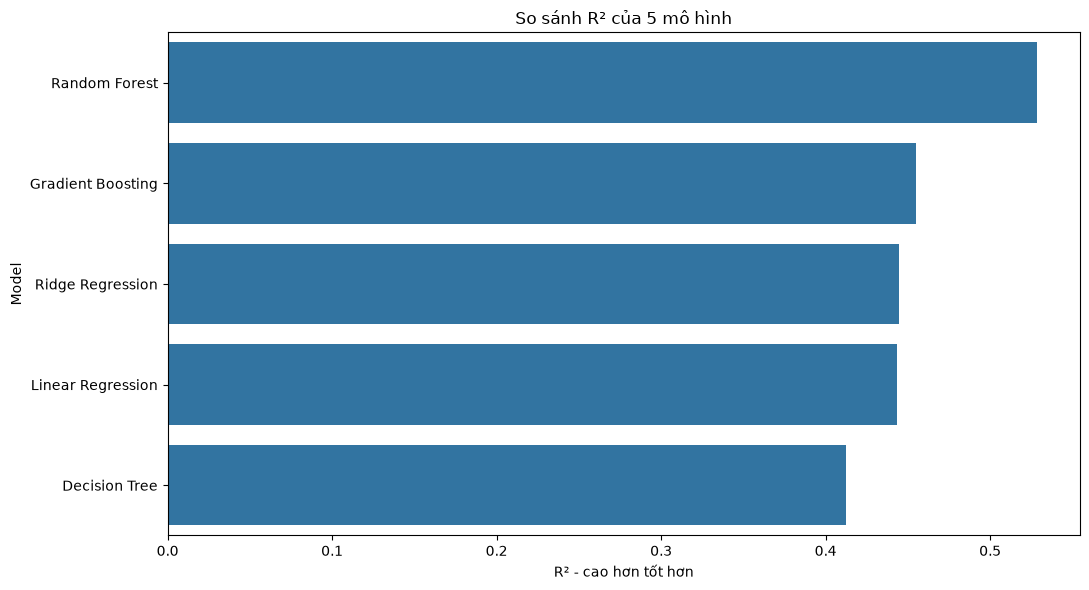

In [15]:
plot_df = results_df.sort_values("RMSE")
plt.figure(figsize=(11, 6))
sns.barplot(data=plot_df, x="RMSE", y="Model")
plt.title("So sánh RMSE của 5 mô hình")
plt.xlabel("RMSE - thấp hơn tốt hơn")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

plot_df = results_df.sort_values("R2", ascending=False)
plt.figure(figsize=(11, 6))
sns.barplot(data=plot_df, x="R2", y="Model")
plt.title("So sánh R² của 5 mô hình")
plt.xlabel("R² - cao hơn tốt hơn")
plt.ylabel("Model")
plt.tight_layout()
plt.show()


In [16]:
MODEL_FILE = "best_house_price_model.pkl"
joblib.dump(best_pipeline, MODEL_FILE)

metadata = {
    "model_name": best_model_name,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "target": TARGET,
    "random_state": RANDOM_STATE
}
with open("house_model_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print("Saved model:", os.path.abspath(MODEL_FILE))
print("Best model:", best_model_name)


Saved model: C:\Users\The Hoang\Du_Doan_Gia_Nha\best_house_price_model.pkl
Best model: Random Forest


In [17]:
loaded = joblib.load("best_house_price_model.pkl")
one_row = X_test.iloc[[0]]
pred = float(loaded.predict(one_row)[0])
print("Example prediction:", pred)
print("Actual price:", float(y_test.iloc[0]))


Example prediction: 8.301011428571428
Actual price: 8.3


C:\Users\The Hoang\AppData\Local\Temp\ipykernel_18700\4066113811.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=model_df[model_df['Bedrooms'] <= 9], x="Bedrooms", y="Price", palette="Set3")


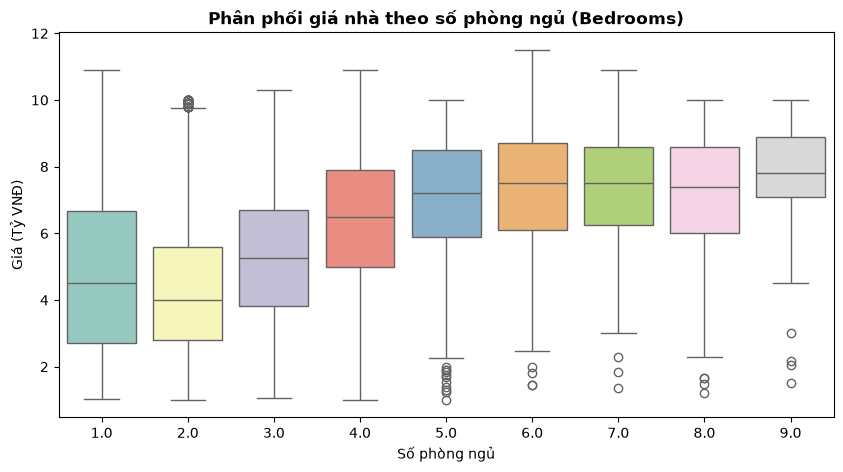

In [18]:
# 1. Phân phối Price theo Bedrooms (Boxplot)
plt.figure(figsize=(10, 5))
sns.boxplot(data=model_df[model_df['Bedrooms'] <= 9], x="Bedrooms", y="Price", palette="Set3")
plt.title("Phân phối giá nhà theo số phòng ngủ (Bedrooms)", fontweight='bold')
plt.xlabel("Số phòng ngủ")
plt.ylabel("Giá (Tỷ VNĐ)")
plt.savefig('house_price_bedrooms_boxplot.png', dpi=300)
plt.show()

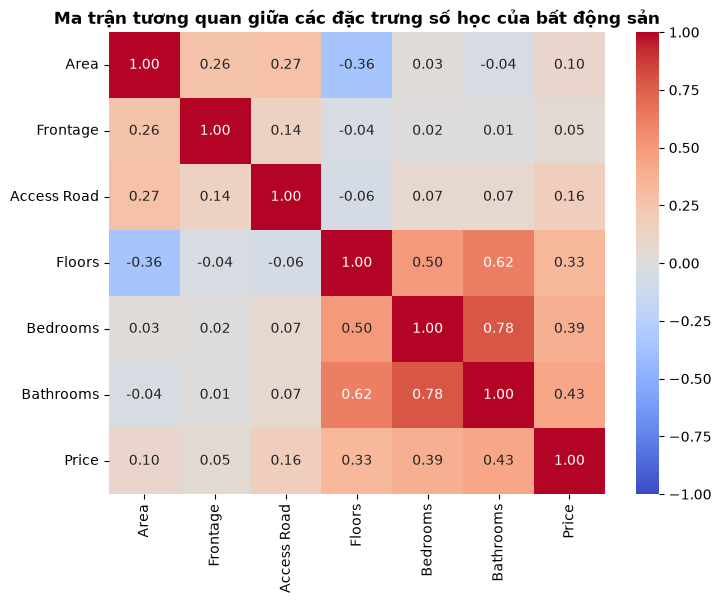

In [19]:
# 2. Ma trận tương quan giữa các thuộc tính số (Correlation Heatmap)
plt.figure(figsize=(8, 6))
corr_house = model_df[EXPECTED_NUMERIC + ['Price']].corr()
sns.heatmap(corr_house, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Ma trận tương quan giữa các đặc trưng số học của bất động sản", fontweight='bold')
plt.savefig('house_correlation_heatmap.png', dpi=300)
plt.show()

C:\Users\The Hoang\AppData\Local\Temp\ipykernel_18700\3333011064.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df.sort_values("MAE"), x="MAE", y="Model", ax=axes[0], palette="mako")
C:\Users\The Hoang\AppData\Local\Temp\ipykernel_18700\3333011064.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df.sort_values("MAPE (%)"), x="MAPE (%)", y="Model", ax=axes[1], palette="rocket")


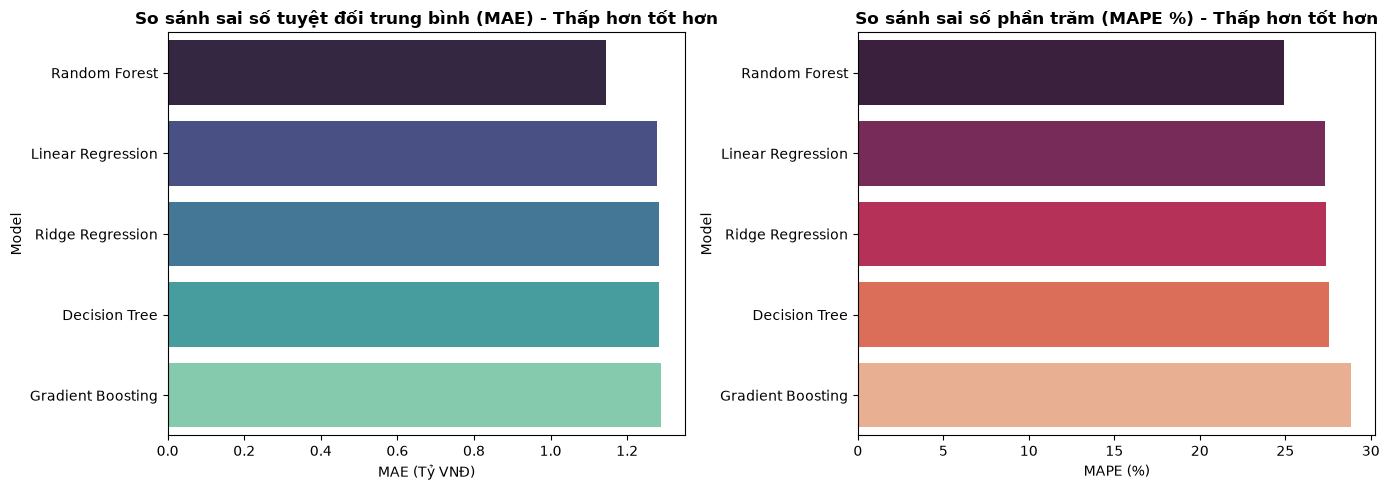

In [20]:
# 3. Biểu đồ so sánh MAE và MAPE giữa 5 mô hình hồi quy
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=results_df.sort_values("MAE"), x="MAE", y="Model", ax=axes[0], palette="mako")
axes[0].set_title("So sánh sai số tuyệt đối trung bình (MAE) - Thấp hơn tốt hơn", fontweight='bold')
axes[0].set_xlabel("MAE (Tỷ VNĐ)")

sns.barplot(data=results_df.sort_values("MAPE (%)"), x="MAPE (%)", y="Model", ax=axes[1], palette="rocket")
axes[1].set_title("So sánh sai số phần trăm (MAPE %) - Thấp hơn tốt hơn", fontweight='bold')
axes[1].set_xlabel("MAPE (%)")
plt.tight_layout()
plt.savefig('house_mae_mape_comparison.png', dpi=300)
plt.show()

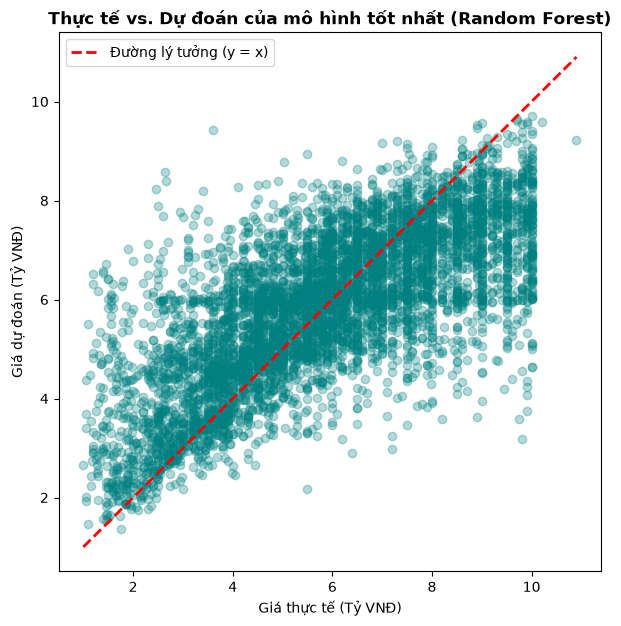

In [21]:
# 4. Biểu đồ Actual vs. Predicted (Thực tế vs. Dự đoán) của Best Model (Random Forest)
y_pred_best = predictions[best_model_name]
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_best, alpha=0.3, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Đường lý tưởng (y = x)')
plt.title(f"Thực tế vs. Dự đoán của mô hình tốt nhất ({best_model_name})", fontweight='bold')
plt.xlabel("Giá thực tế (Tỷ VNĐ)")
plt.ylabel("Giá dự đoán (Tỷ VNĐ)")
plt.legend()
plt.savefig('house_actual_vs_predicted.png', dpi=300)
plt.show()

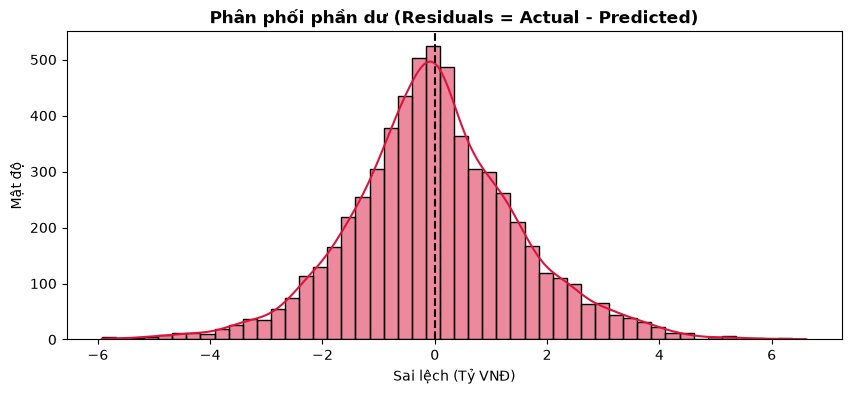

In [22]:
# 5. Phân phối phần dư sai số (Residual Distribution Plot)
residuals = y_test - y_pred_best
plt.figure(figsize=(10, 4))
sns.histplot(residuals, kde=True, bins=50, color='crimson')
plt.title("Phân phối phần dư (Residuals = Actual - Predicted)", fontweight='bold')
plt.xlabel("Sai lệch (Tỷ VNĐ)")
plt.ylabel("Mật độ")
plt.axvline(0, color='black', linestyle='--', lw=1.5)
plt.savefig('house_residuals_distribution.png', dpi=300)
plt.show()